<h1 align="center", style="color:black:">PLV value analysis</h1>

 <sub><sup>(Aydore S, Pantazis D, Leahy RM. A note on the phase locking value and its properties. Neuroimage. 2013 Jul 1;74:231-44. doi: 10.1016/j.neuroimage.2013.02.008. Epub 2013 Feb 19. PMID: 23435210; PMCID: PMC3674231)</sub></sup>

  <sub><sup>Praneeth Namburi: https://praneethnamburi.com/2011/08/10/plv/  </sub></sup>
  
  <sub><sup>  Difference between IIR and FIR filters: a practical design guide: https://www.advsolned.com/difference-between-iir-and-fir-filters-a-practical-design-guide/ </sub></sup>
  


Phase locking value and its sub. methods used in analysis of nonlinear chaotic system. Mentions of Local Field Potentials LFPs. 

- Its the absolute value of the mean phase difference between two signals expressed as a complex |unit-length| vector
- For every time point in data I can exctract exact measure of connectivity: that means we can later on observe transient changes without time window analysis: ONE MEASURE
- One PLV for every el. pair: for 28 EEG its 378 PLV courses based on combination without repetition
- """One PLV time course is computed over multiple trials. In practice, I have observed that this metric is suitable for datasets with a large number of trials. It is good to have a few hundred trials for each experimental condition for which long range synchronization is to be quantified using PLV""" [2]

<i>Note that this metric does not care about the co-variation in the power of the EEG signal between two electrodes. -> kovariance udává pouze směr tohoto vztahu, zatímco korelace je standardizovaná (bez jednotek) a určuje jak směr, tak i přesnou sílu a těsnost vztahu

![alt text](./../data/ReferencePictures/PLV.png "Title")

**Filtering data**: first step (i could filter alpha bands to specify interest, but first lets do global PLV)
Digital filters are divided into the following two categories:

    Infinite impulse response (IIR)
    Finite impulse response (FIR)

FIR for time domain and IIR for specific frequencies bands (put it realy simplified)

RULE OF THUMB 4-5 cycles of the desired EEG rhy. 

<i><sub><sup> As an example, consider gamma rhythm (35-45 Hz). Here, one cycle is about 25 ms and I would set the order of the filter to be 100 ms. If the sampling rate is 500 Hz, then the filter order would be 50 data points. The 25 ms cycle length for the 35–45 Hz gamma rhythm is derived by calculating the period (\(T=1/f\)) of the 40 Hz center frequency, which equals 0.025 seconds or 25 milliseconds. A 100 ms filter length is then recommended to encompass four full cycles for robust filtration, which at a 500 Hz sampling rate results in a 50-data-point filter.

**Hilbert transformation**: transform real signal to analytic one. More spec. it converts number data format into quantified data of rising and falling

<i> God gave us filtered and procesed signal of EEG (give gamma), then we will move signal by phase shift by 90 digrees and call it $x^{*}t$</i>

<b>Analythic signal</b>:$$ zt = xt + x^{*}t$$

<b>Istantaneous Amlitude</b>: is envelope -obalka- of signal, it represents power of oscilation 
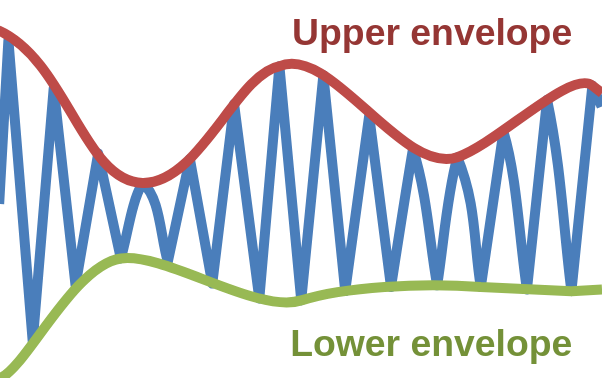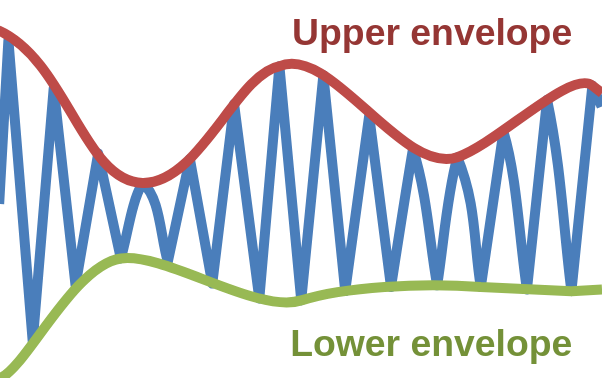

<b>Instantaneous Phase</b>: $\theta(t)$
this is angle of the signal vector in the complex plane at time t. We can compute it using arctan function <code> atan2 </code>
~~ Okamžitá fáze ~~

<h3>What manka remembers from talking to: </h3>

**Wrong information ahead!!**

- Hilbertova transformacia je něco co používáme na horní ohraničení signálu (amplituda, frekvence), používá se k tomu posun o PÍ, což je polovina jedný frekvence (signál udělá sinusoidu), vezmeme tedy signál, zjistíme jeho "imaginární složku". To je signál posunutý o PÍ. Tento posunutý signál odečteme od reálné hodnoty signálu

- Každá sinusová funkce se dá zobrazit na kružnici, teno fakt využijeme spolu s Hilbertovou transformací

- Re signál a Imaginární signál dáme pod sebe. Zakreslíme si fáze. Pak porovnáváme hodnoty kde se jednotlivé body z fázové funkce vyskytují. Obrázek(imput) Toto lze vyobrazit na kružnici kde je Im složka a Re složka každého bodu a to nám vytvoří jednotkový vektor s úhlem. Následně všechny tyto složky navzájem sečteme a vydělíme počtem vektorů (jakožto normalizace). Pokud nám výjde PLV k jedné pak je od sebe funkce velmi podobná. Obrázek(input 2) pokud výjde nějaká hodnota alfa (blížící se k nule) pak je funkce od sebe velmi náhodná. Toto porovnání slouží k vytvoření horní obálky funkce či pro korelaci dvou funkcí.



![alt text](./../data/ReferencePictures/Drawings/1000033527.jpg "Title")

![alt text](./../data/ReferencePictures/Drawings/1000033528.jpg "Title")

![alt text](./../data/ReferencePictures/Drawings/1000033529.jpg "Title")

<h3>Co je actually pravda:</h3>

- Hilbert creates Analytitc signal $z(t)=x(t)+iH(x(t))$ where x(t) is the original function and H(x(t)) is Hilbert transformation. From the Analithic signal it is possible to get the envelope by $A(t)=∣z(t)∣$ and NOWphase $ϕ(t)=arg(z(t))$

- Hilbert tranformation uses phase shift by PI/2 (90 degree)

- The i before $H(x(t))$ is Imaginary

- We are creating Complex number by addition to positive spectra of circle one.

**$$z(t)=x(t)+iH(x(t))$$**

- Every sinusoid can be aproximated and written to circle represented by rotating vector $eiϕ=cosϕ+isinϕ$

- Point t on circle is represented by these two values: $(Re(t),Im(t))$ and by angle: $ϕ(t)$

- When we get through 2 Hilberts 2 phases then we can compute their difference: $$Δϕ(t)=ϕ1​(t)−ϕ2​(t)$$

- Every 2 phases substractin we will normalise to the vector of size 1 by $eiΔϕ$

- **When PLV is equal to 1 then difference between phases shift is konstant. They are not the same by rule**
    - As example: sin(wt) and 10sin(wt + 40deg) have PLV 1 but the amplitudes are not the same at all.
    - THE PLV is used to compute synchronisation phases of two signals 


<h2>Phase Locking Value</h2>

![alt text](./../data/ReferencePictures/PLV.png "Title")

So we need to do Hilbert on x, y electrodes to get $\phi_x$ and $\phi_y $ angles(phases), then use this shit: $$\begin{split}PLV_t = \frac{1}{N} \left |
\sum_{n=1}^N \exp(i \cdot \theta(t, n)) \right | \\\end{split}$$

where $\theta(t, n) = \phi_x(t, n) - \phi_y(t, n)$

Bandpass filter -> Hilbert -> Analytic -> Extract phases -> Compute phase differences

*Trial with loaded subject*

In [2]:
import mne
import numpy as np
import warnings as w
import matplotlib.pyplot as plt
from elephant.phase_analysis import phase_locking_value
from scipy.signal import decimate
from elephant.signal_processing import butter

path = './../data/C01/C01_2024-11-16_10-44-51_RS_before_ica.fif'

subject = mne.io.read_raw_fif(path, preload=True)
montage = mne.channels.make_standard_montage("standard_1005")

subject.set_montage(montage)

Opening raw data file ./../data/C01/C01_2024-11-16_10-44-51_RS_before_ica.fif...
    Range : 0 ... 4287999 =      0.000 ...   536.000 secs
Ready.
Opening raw data file /home/manka-roblik/AnalysisBooredEEG/Notebook/../data/C01/C01_2024-11-16_10-44-51_RS_before_ica-1.fif...
    Range : 4288000 ... 4807672 =    536.000 ...   600.959 secs
Ready.


/tmp/ipykernel_56915/3151912863.py:11: RuntimeWarning: This filename (./../data/C01/C01_2024-11-16_10-44-51_RS_before_ica.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  subject = mne.io.read_raw_fif(path, preload=True)


Reading 0 ... 4807672  =      0.000 ...   600.959 secs...


<Raw | C01_2024-11-16_10-44-51_RS_before_ica.fif, 125 x 4807673 (601.0 s), ~4.48 GiB, data loaded>

<h3>Filtering data</h3>

supposed to use fir filtering because of the artifacts, we want less phase distortion, stability. Not artifitialy smooth data. 

In [ ]:
s_freq = int(subject.info['sfreq'])
new_freq = 100

s_data = subject.get_data(picks="eeg")
s_filtered = decimate(
    butter(s_data,
            highpass_frequency=1,
            lowpass_frequency=45,
            filter_function="sosfiltfilt",
            axis = 1, 
            sampling_frequency=subject.info['sfreq']),
    q = int(s_freq/new_freq),
    ftype='fir',
    axis=1,
    zero_phase=True
)

In [10]:
subject.filter(
    1,
    45,
    method='fir'
)

subject.resample(100)

s_data = subject.get_data(picks="eeg")

#VISUALISE IT LATER!!

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 45 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 1.00, 45.00 Hz: -6.02, -6.02 dB

Sampling frequency of the instance is already 100.0, returning unmodified.


<h3>Hilbert transformation by SciPy</h3>

**Singular integral**: integral becomes infinite at some point. Like x -> 0 is infinity

**Harmonic analzsis**: study about representing function via waves 

**PDR or PDEs** (partial differential equations) 

**Integral operator**: mathematical "zobrazeni" mapping/transformation that transforms one function to another using integral. Like a group operator but integral one

**Kernel function**: Jadro, thats the fuction K(x,y) that defines how the operator transforms the input func.

WIKI:
<sub><sup>In mathematics, singular integrals are central to harmonic analysis and are intimately connected with the study of partial differential equations. Broadly speaking a singular integral is an integral operator</sub></sup>

   $$ T ( f ) ( x ) = ∫ K ( x , y ) f ( y ) d y , {\displaystyle T(f)(x)=\int K(x,y)f(y)\,dy,}$$
<sub><sup>
whose kernel function K : R n × R n → R {\displaystyle K:\mathbb {R} ^{n}\times \mathbb {R} ^{n}\to \mathbb {R} } is singular along the diagonal x = y {\displaystyle x=y}. Specifically, the singularity is such that | K ( x , y ) | {\displaystyle |K(x,y)|} is of size | x − y | − n {\displaystyle |x-y|^{-n}} asymptotically as | x − y | → 0 {\displaystyle |x-y|\to 0}. Since such integrals may not in general be absolutely integrable, a rigorous definition must define them as the limit of the integral over | y − x | → ϵ {\displaystyle |y-x|\to \epsilon } as ϵ → 0 {\displaystyle \epsilon \to 0}, but in practice this is a technicality. Usually further assumptions are required to obtain results such as their boundedness on Lp spaces, for example L p ( R n ) {\displaystyle L^{p}(\mathbb {R} ^{n})}. </sub></sup>

**Archetypyc Singular Integral is the HIlbert transform H**

Kernel:
$$ {\displaystyle K(x)=1/(\pi x)}$$
Hilbert:

$${\displaystyle \operatorname {H} (u)(t)={\frac {1}{\pi }}\,\operatorname {p.v.} \int _{-\infty }^{+\infty }{\frac {u(\tau )}{t-\tau }}\,\mathrm {d} \tau ,}$$

We solve it with limit trick

**Cauchy principal value (P.V.)**: Cauchyho hlavni hodnota - rigorous method to assign a finite value to certain divergent integrals

Convolution is mathematical operation on two function that shows how the shape of one is modified by the other. Where g(x) is kernel
$$(f*g)(x) = \int_{-\infty }^{+\infty } f(\alpha)g(x - \alpha) d\alpha$$

<h4>And this all is just shifting function by +-90 degrees</h4>

In [5]:
subject.get_data(picks="eeg").shape

(124, 60096)

In [9]:
import scipy.signal 
from scipy.signal import hilbert

#HILBERT 
analytic_signal = hilbert(s_data, axis=1)

#GET PHASES
as_phases = np.angle(analytic_signal)

(124, 60096)

<h1>Filtering issues with tissues </h1>

**IIR Filters**
infinite inpulse response 

- for analysis where linear phases is not too important cos of the memomory beeing limited
- requires less memory cos of the lot less used coeficient
- real time control
- nonlinear near cut off frewuencies
- requires lo more scaling and numeric overflow analysis
- FASTA, can be used with filtfilt or sosfiltfilt to simulate linearity

---

**FIR Filers**
finite impulse response 

- where more memory and computing time is awailable
- is all zero structured
- no phase distortion cos all of the freq are shifted in the same time by same amount
- can become unstable cos they have no feedback (they doesnt compute their present output based on the previous one)
- more costumisable
- problemable in real time closed loop control as it doesnt achieve loop stabilitz
- maximum of 50-60 polynomial roots
- popular in EEG

can be used with minimum phase filters (zero fliping filter) to help with the N/2 latency

---

lets go again. SO I want to take data, make down sample them, pick wavelength (or pick wave then downsample) then do Hilfert on all of them and lastly compute their PLV to create .npy dictionary matrix or something like that. To filter I can use FIR or IIR (with FIR it can be long and there is something as latency rate of N/2 or with IIR it can be "sugestive" like the problem can propagate or make itself smaller) to compute Hilbert I can use scipy or MNEs apply_hilbert and then use elephant phase_locking_value function

In [1]:
import mne
import numpy as np
import warnings as w
import os
import matplotlib.pyplot as plt
from elephant.phase_analysis import phase_locking_value
from scipy.signal import decimate
from elephant.signal_processing import butter
from scipy.signal import hilbert

path = './../data/C01/C01_2024-11-16_10-44-51_RS_before_ica.fif'

subject = mne.io.read_raw_fif(path, preload=True)
montage = mne.channels.make_standard_montage("standard_1005")

subject.set_montage(montage)

Opening raw data file ./../data/C01/C01_2024-11-16_10-44-51_RS_before_ica.fif...
    Range : 0 ... 4287999 =      0.000 ...   536.000 secs
Ready.
Opening raw data file /home/manka-roblik/AnalysisBooredEEG/Notebook/../data/C01/C01_2024-11-16_10-44-51_RS_before_ica-1.fif...
    Range : 4288000 ... 4807672 =    536.000 ...   600.959 secs
Ready.


/tmp/ipykernel_10890/657539944.py:16: RuntimeWarning: This filename (./../data/C01/C01_2024-11-16_10-44-51_RS_before_ica.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  subject = mne.io.read_raw_fif(path, preload=True)


Reading 0 ... 4807672  =      0.000 ...   600.959 secs...


<Raw | C01_2024-11-16_10-44-51_RS_before_ica.fif, 125 x 4807673 (601.0 s), ~4.48 GiB, data loaded>

In [7]:
out_dir = "PLV_matrices_simple"
os.makedirs(out_dir, exist_ok=True)

s_freq = int(subject.info['sfreq'])
new_freq = 200

s_data = subject.get_data(picks="eeg")

s_filtered = decimate(
    butter(s_data,
            highpass_frequency=1,
            lowpass_frequency=45,
            filter_function="sosfiltfilt",
            axis = 1, 
            sampling_frequency=subject.info['sfreq']),
    q = int(s_freq/new_freq),
    ftype='fir',
    axis=1,
    zero_phase=True
)

s_hilbert = hilbert(s_filtered, axis=1)
s_phases = np.angle(s_hilbert)

s_phases.shape

window_size = 5 * new_freq
step_size = window_size

n_channels, n_samples = s_phases.shape

maximal = 0
for start in range(0, n_samples-window_size+1, new_freq):

    end = start + window_size
    window = s_phases[:, start:end]

    matrix = np.eye(n_channels) # zeros everywhere else then diagonal ones

    for i in range(n_channels):
        for j in range(i+1, n_channels):

            theta = window[i] - window[j]

            value = np.abs(
                np.mean(
                    np.exp(1j * theta)
                )
            )

            matrix[i, j] = value
            matrix[j, i] = value

    np.save(
        os.path.join(
            out_dir,
            f"plv_{start//new_freq:04d}.npy"
        ),
        matrix
    )    

    # if(maximal == 10): ctrl lomeno
    #     break 
    maximal = maximal +1